In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import os

# Force working directory to repo root
os.chdir("/scratch2/ij292/tnp-crps")

## Sawtooth Interpolation Gate Dropout Table

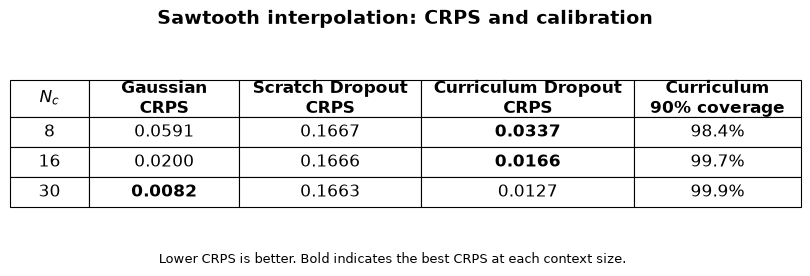

Saved: results/synthetic_1d/sawtooth_interpolation_gate_dropout_curriculum/sawtooth_crps_calibration_table.pdf


In [1]:

# ---------------------------------------------------------------------
# Output
# ---------------------------------------------------------------------
output_dir = Path(
    "results/synthetic_1d/"
    "sawtooth_interpolation_gate_dropout_curriculum"
)
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "sawtooth_crps_calibration_table.pdf"

if output_path.exists():
    raise FileExistsError(
        f"Refusing to overwrite existing file: {output_path}"
    )


# ---------------------------------------------------------------------
# Table data
# ---------------------------------------------------------------------
columns = [
    r"$N_c$",
    "Gaussian\nCRPS",
    "Scratch Dropout\nCRPS",
    "Curriculum Dropout\nCRPS",
    "Curriculum\n90% coverage",
]

rows = [
    ["8",  "0.0591", "0.1667", "0.0337", "98.4%"],
    ["16", "0.0200", "0.1666", "0.0166", "99.7%"],
    ["30", "0.0082", "0.1663", "0.0127", "99.9%"],
]


# ---------------------------------------------------------------------
# Figure
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10.2, 2.6))
ax.axis("off")

table = ax.table(
    cellText=rows,
    colLabels=columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.10, 0.19, 0.23, 0.27, 0.21],
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.0, 1.8)


# ---------------------------------------------------------------------
# Formatting
# ---------------------------------------------------------------------
for (row_idx, col_idx), cell in table.get_celld().items():
    cell.set_linewidth(0.8)

    if row_idx == 0:
        cell.set_text_props(weight="bold")
        cell.set_height(cell.get_height() * 1.25)

# Bold the lowest CRPS value at each context size:
# Nc=8  -> curriculum
# Nc=16 -> curriculum
# Nc=30 -> Gaussian
table[(1, 3)].set_text_props(weight="bold")
table[(2, 3)].set_text_props(weight="bold")
table[(3, 1)].set_text_props(weight="bold")


ax.set_title(
    "Sawtooth interpolation: CRPS and calibration",
    fontsize=14,
    fontweight="bold",
    pad=14,
)

fig.text(
    0.5,
    0.035,
    "Lower CRPS is better. Bold indicates the best CRPS at each context size.",
    ha="center",
    fontsize=9,
)

plt.savefig(
    output_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.12,
)

plt.show()

print(f"Saved: {output_path}")

## Fixed Context Evaluation

In [5]:
paths = {
    "Dropout, train Nc=64": Path(
        "results/sawtooth/ar_nc64_metrics_v1/"
        "sawtooth_ar_summary.csv"
    ),
    "Dropout, train Nc=96": Path(
        "results/sawtooth/ar_nc96_metrics_v1/"
        "sawtooth_ar_summary.csv"
    ),
    "Dropout vs StochLN, train Nc=128": Path(
        "results/sawtooth/ar_nc128_models_metrics_v1/"
        "sawtooth_ar_summary.csv"
    ),
}


In [6]:
frames = []

for experiment, path in paths.items():
    if not path.is_file():
        raise FileNotFoundError(path)

    frame = pd.read_csv(path)
    frame.insert(0, "experiment", experiment)
    frames.append(frame)

combined = pd.concat(
    frames,
    ignore_index=True,
)

columns = [
    "experiment",
    "nc",
    "source",
    "num_tasks",
    "rmse",
    "crps",
    "energy",
    "coverage90",
    "coverage95",
    "width90",
    "width95",
    "runtime_s_per_task",
]

display(
    combined[columns].sort_values(
        ["nc", "source"]
    )
)

,experiment,nc,source,num_tasks,rmse,crps,energy,coverage90,coverage95,width90,width95,runtime_s_per_task
0,"Dropout, train Nc=64",48,"Dropout CRPS, train Nc=64",4096,0.078370,0.013146,0.124174,0.991455,0.995712,0.130156,0.151994,0.044164
1,"Dropout, train Nc=64",48,"Trivial U(0,1)",4096,0.291859,0.166878,0.808265,0.863663,0.913010,0.864979,0.912934,0.000000
2,"Dropout, train Nc=96",80,"Dropout CRPS, train Nc=96",4096,0.066947,0.009817,0.092317,0.992325,0.995956,0.098305,0.114776,0.073065
3,"Dropout, train Nc=96",80,"Trivial U(0,1)",4096,0.291435,0.166726,0.807007,0.865555,0.913223,0.864979,0.912934,0.000000
4,"Dropout vs StochLN, train Nc=128",112,"Dropout CRPS, train Nc=128",4096,0.061099,0.008125,0.078048,0.993210,0.996262,0.083289,0.097197,0.094672
5,"Dropout vs StochLN, train Nc=128",112,"StochLN CRPS, train Nc=128",4096,0.291759,0.166731,0.807565,0.872238,0.929413,0.873060,0.939661,0.096992
6,"Dropout vs StochLN, train Nc=128",112,"Trivial U(0,1)",4096,0.291274,0.166422,0.806364,0.865128,0.913940,0.864979,0.912934,0.000000


## Sawtooth Context-Curriculum Experiment

Evaluation protocol:

- 4,096 independent sawtooth tasks
- initial context size: \(N_c=48\)
- 16 autoregressive anchors
- completed context size: \(N_c=64\)
- 50 autoregressive rollouts per task
- independently random anchor traversal per rollout
- Stochastic LayerNorm noise refreshed at every AR step

The metrics are calculated from the raw autoregressive samples at the
16 anchor locations. The denoised function paths are used only for
qualitative figures.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    """Locate the repository whether Jupyter starts in root or notebooks/."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "experiments").is_dir()
            and (candidate / "tnp_crps").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the tnp-crps repository root."
    )


ROOT = find_repo_root(Path.cwd())

RESULT_DIR = (
    ROOT
    / "results"
    / "synthetic_1d"
    / "sawtooth_context_curriculum_ar_4096_v1"
)

SUMMARY_PATH = (
    RESULT_DIR
    / "sawtooth_ar_summary.csv"
)

PER_TASK_PATH = (
    RESULT_DIR
    / "sawtooth_ar_per_task.csv"
)

RESOLVED_PATH = (
    RESULT_DIR
    / "sawtooth_ar_resolved.json"
)

NOTEBOOK_OUTPUT_DIR = (
    RESULT_DIR
    / "notebook_outputs"
)

NOTEBOOK_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

for path in (
    SUMMARY_PATH,
    PER_TASK_PATH,
    RESOLVED_PATH,
):
    if not path.is_file():
        raise FileNotFoundError(path)

print("Repository root:", ROOT)
print("Result directory:", RESULT_DIR)
print("Notebook outputs:", NOTEBOOK_OUTPUT_DIR)

Repository root: /scratch2/ij292/tnp-crps
Result directory: /scratch2/ij292/tnp-crps/results/synthetic_1d/sawtooth_context_curriculum_ar_4096_v1
Notebook outputs: /scratch2/ij292/tnp-crps/results/synthetic_1d/sawtooth_context_curriculum_ar_4096_v1/notebook_outputs


In [2]:
summary = pd.read_csv(SUMMARY_PATH)
per_task = pd.read_csv(PER_TASK_PATH)

with RESOLVED_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    resolved_protocol = json.load(handle)

print("Summary columns:")
print(summary.columns.tolist())

print()
print("Summary:")
display(summary)

print()
print("Per-task rows:", len(per_task))
print("Sources:", sorted(per_task["source"].unique()))

Summary columns:
['nc', 'source', 'num_tasks', 'rmse', 'rmse_task_se', 'crps', 'crps_se', 'energy', 'energy_se', 'coverage90', 'coverage90_se', 'coverage95', 'coverage95_se', 'width90', 'width90_se', 'width95', 'width95_se', 'runtime_s_per_task', 'runtime_s_per_task_se', 'trivial_rmse', 'trivial_crps', 'trivial_energy', 'delta_rmse_vs_trivial', 'delta_crps_vs_trivial', 'delta_energy_vs_trivial']

Summary:


,nc,source,num_tasks,rmse,rmse_task_se,crps,crps_se,energy,energy_se,coverage90,...,width95,width95_se,runtime_s_per_task,runtime_s_per_task_se,trivial_rmse,trivial_crps,trivial_energy,delta_rmse_vs_trivial,delta_crps_vs_trivial,delta_energy_vs_trivial
0,48,Gaussian curriculum,4096,0.033668,0.000493,0.002395,0.000090,0.028778,0.001297,0.923233,...,0.022202,0.000645,0.010865,0.000009,0.291859,0.166878,0.808265,-0.258191,-0.164483,-0.779487
1,48,Dropout curriculum,4096,0.052102,0.000670,0.005782,0.000103,0.057162,0.001480,0.996918,...,0.070365,0.000699,0.019428,0.000011,0.291859,0.166878,0.808265,-0.239758,-0.161096,-0.751103
2,48,StochLN curriculum,4096,0.292333,0.000537,0.167066,0.000316,0.809119,0.001493,0.869659,...,0.947687,0.000281,0.021060,0.000013,0.291859,0.166878,0.808265,0.000474,0.000188,0.000854
3,48,"Trivial U(0,1)",4096,0.291859,0.000533,0.166878,0.000317,0.808265,0.001503,0.863663,...,0.912934,0.000147,0.000000,0.000000,0.291859,0.166878,0.808265,0.000000,0.000000,0.000000



Per-task rows: 16384
Sources: ['Dropout curriculum', 'Gaussian curriculum', 'StochLN curriculum', 'Trivial U(0,1)']


In [3]:
expected_model_tokens = {
    "gaussian",
    "dropout",
    "stoch",
    "trivial",
}

observed_sources = {
    str(source).lower()
    for source in summary["source"]
}

for token in expected_model_tokens:
    if not any(
        token in source
        for source in observed_sources
    ):
        raise RuntimeError(
            f"Could not find source containing {token!r}. "
            f"Observed sources: {sorted(observed_sources)}"
        )

if "nc" in summary.columns:
    print(
        "Context sizes in summary:",
        sorted(summary["nc"].unique()),
    )

    if 48 not in set(summary["nc"]):
        raise RuntimeError(
            "Expected the AR evaluation to start at Nc=48."
        )

task_counts = (
    per_task
    .groupby("source")["task_id"]
    .agg(
        count="count",
        unique="nunique",
        minimum="min",
        maximum="max",
    )
)

display(task_counts)

assert (task_counts["count"] == 4096).all()
assert (task_counts["unique"] == 4096).all()
assert (task_counts["minimum"] == 0).all()
assert (task_counts["maximum"] == 4095).all()

print("Matched 4,096-task evaluation integrity check passed.")

Context sizes in summary: [np.int64(48)]


,count,unique,minimum,maximum
source,,,,
Dropout curriculum,4096,4096,0,4095
Gaussian curriculum,4096,4096,0,4095
StochLN curriculum,4096,4096,0,4095
"Trivial U(0,1)",4096,4096,0,4095


Matched 4,096-task evaluation integrity check passed.


In [4]:
def display_model_name(source: str) -> str:
    key = str(source).lower()

    if "trivial" in key:
        return "Trivial U(0,1)"

    if "dropout" in key:
        return "Dropout CRPS M4 (p=0.10)"

    if "stoch" in key:
        return "StochLN CRPS M4"

    if "gaussian" in key:
        return "Gaussian TNP NLL"

    raise ValueError(
        f"Unrecognised source name: {source!r}"
    )


required_columns = [
    "source",
    "rmse",
    "crps",
    "energy",
    "coverage90",
    "coverage95",
    "width90",
    "width95",
]

missing_columns = [
    column
    for column in required_columns
    if column not in summary.columns
]

if missing_columns:
    raise KeyError(
        f"Missing summary columns: {missing_columns}"
    )

table = summary.copy()

if "nc" in table.columns:
    table = table[
        table["nc"] == 48
    ].copy()

table["Model"] = table["source"].map(
    display_model_name
)

model_order = [
    "Gaussian TNP NLL",
    "Dropout CRPS M4 (p=0.10)",
    "StochLN CRPS M4",
    "Trivial U(0,1)",
]

table["Model"] = pd.Categorical(
    table["Model"],
    categories=model_order,
    ordered=True,
)

table = (
    table
    .sort_values("Model")
    .rename(
        columns={
            "rmse": "RMSE ↓",
            "crps": "CRPS ↓",
            "energy": "Energy ↓",
            "coverage90": "Cov90",
            "coverage95": "Cov95",
            "width90": "Width90 ↓",
            "width95": "Width95 ↓",
        }
    )
    [
        [
            "Model",
            "RMSE ↓",
            "CRPS ↓",
            "Energy ↓",
            "Cov90",
            "Cov95",
            "Width90 ↓",
            "Width95 ↓",
        ]
    ]
    .reset_index(drop=True)
)

if len(table) != 4:
    raise RuntimeError(
        f"Expected four rows, found {len(table)}."
    )

table

,Model,RMSE ↓,CRPS ↓,Energy ↓,Cov90,Cov95,Width90 ↓,Width95 ↓
0,Gaussian TNP NLL,0.033668,0.002395,0.028778,0.923233,0.955215,0.018585,0.022202
1,Dropout CRPS M4 (p=0.10),0.052102,0.005782,0.057162,0.996918,0.998627,0.060272,0.070365
2,StochLN CRPS M4,0.292333,0.167066,0.809119,0.869659,0.927277,0.873016,0.947687
3,"Trivial U(0,1)",0.291859,0.166878,0.808265,0.863663,0.913010,0.864979,0.912934


In [5]:
metric_columns = [
    column
    for column in table.columns
    if column != "Model"
]

display(
    table.style
    .format(
        {
            column: "{:.3f}"
            for column in metric_columns
        }
    )
    .hide(axis="index")
    .set_properties(
        subset=["Model"],
        **{
            "text-align": "left",
        },
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                ],
            },
            {
                "selector": "th:first-child",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Model,RMSE ↓,CRPS ↓,Energy ↓,Cov90,Cov95,Width90 ↓,Width95 ↓
Gaussian TNP NLL,0.034,0.002,0.029,0.923,0.955,0.019,0.022
Dropout CRPS M4 (p=0.10),0.052,0.006,0.057,0.997,0.999,0.060,0.070
StochLN CRPS M4,0.292,0.167,0.809,0.870,0.927,0.873,0.948
"Trivial U(0,1)",0.292,0.167,0.808,0.864,0.913,0.865,0.913


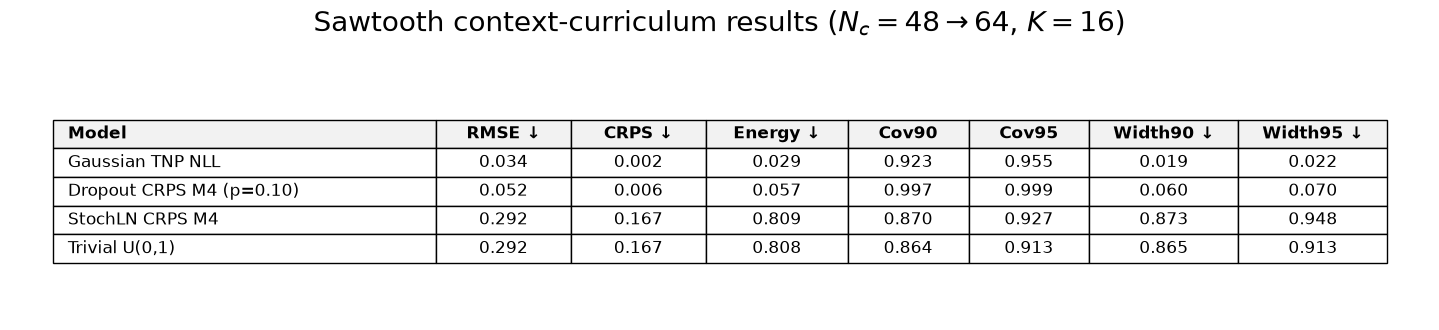

Wrote: /scratch2/ij292/tnp-crps/results/synthetic_1d/sawtooth_context_curriculum_ar_4096_v1/notebook_outputs/sawtooth_context_curriculum_table.png


In [6]:
formatted_table = table.copy()

for column in metric_columns:
    formatted_table[column] = (
        formatted_table[column]
        .map(lambda value: f"{value:.3f}")
    )

fig, ax = plt.subplots(
    figsize=(14.5, 3.4),
)

ax.axis("off")

ax.set_title(
    (
        "Sawtooth context-curriculum results "
        r"($N_c=48 \rightarrow 64$, $K=16$)"
    ),
    fontsize=20,
    pad=22,
)

column_widths = [
    0.27,  # Model
    0.095,
    0.095,
    0.10,
    0.085,
    0.085,
    0.105,
    0.105,
]

rendered_table = ax.table(
    cellText=formatted_table.values,
    colLabels=formatted_table.columns,
    cellLoc="center",
    colLoc="center",
    colWidths=column_widths,
    loc="center",
)

rendered_table.auto_set_font_size(False)
rendered_table.set_fontsize(12)
rendered_table.scale(1.0, 1.75)

for (
    row_index,
    column_index,
), cell in rendered_table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(1.0)

    if row_index == 0:
        cell.set_facecolor("#F2F2F2")
        cell.get_text().set_weight("bold")

    if column_index == 0:
        cell.get_text().set_ha("left")
        cell.PAD = 0.04

fig.tight_layout()

table_png_path = (
    NOTEBOOK_OUTPUT_DIR
    / "sawtooth_context_curriculum_table.png"
)

fig.savefig(
    table_png_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15,
)

plt.show()

print("Wrote:", table_png_path)

In [7]:
indexed = table.set_index("Model")

trivial_crps = float(
    indexed.loc[
        "Trivial U(0,1)",
        "CRPS ↓",
    ]
)

print("CRPS reduction relative to Trivial U(0,1):")

for model_name in (
    "Gaussian TNP NLL",
    "Dropout CRPS M4 (p=0.10)",
    "StochLN CRPS M4",
):
    model_crps = float(
        indexed.loc[
            model_name,
            "CRPS ↓",
        ]
    )

    reduction = (
        100.0
        * (
            trivial_crps
            - model_crps
        )
        / trivial_crps
    )

    print(
        f"  {model_name}: "
        f"{reduction:.2f}%"
    )

CRPS reduction relative to Trivial U(0,1):
  Gaussian TNP NLL: 98.56%
  Dropout CRPS M4 (p=0.10): 96.54%
  StochLN CRPS M4: -0.11%


In [10]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.backends.backend_pdf import PdfPages


def find_repo_root(start: Path) -> Path:
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "experiments").is_dir()
            and (candidate / "tnp_crps").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the tnp-crps repository root."
    )


ROOT = find_repo_root(Path.cwd())

TABLE_OUTPUT_DIR = (
    ROOT
    / "results"
    / "sawtooth"
    / "tables"
)

TABLE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Repository:", ROOT)
print("Table output:", TABLE_OUTPUT_DIR)

Repository: /scratch2/ij292/tnp-crps
Table output: /scratch2/ij292/tnp-crps/results/sawtooth/tables


In [11]:
EXPERIMENTS = {
    "variable_nc14_30": {
        "title": (
            r"Variable context: "
            r"$N_c \in [14,30]$, $\alpha=1$"
        ),
        "folder": (
            ROOT
            / "results"
            / "sawtooth"
            / "ar_context_ladder_nc14_30_v1"
        ),
    },
    "variable_nc14_30_alpha005": {
        "title": (
            r"Variable context: "
            r"$N_c \in [14,30]$, $\alpha=0.05$"
        ),
        "folder": (
            ROOT
            / "results"
            / "sawtooth"
            / "ar_context_ladder_nc14_30_alpha005_v1"
        ),
    },
    "variable_nc48_64": {
        "title": (
            r"Variable context: "
            r"$N_c \in [48,64]$"
        ),
        "folder": (
            ROOT
            / "results"
            / "sawtooth"
            / "ar_context_ladder_nc48_64_v1"
        ),
    },
    "fixed_nc64": {
        "title": r"Fixed context: $N_c=64$",
        "folder": (
            ROOT
            / "results"
            / "sawtooth"
            / "ar_nc64_metrics_v1"
        ),
    },
    "fixed_nc96": {
        "title": r"Fixed context: $N_c=96$",
        "folder": (
            ROOT
            / "results"
            / "sawtooth"
            / "ar_nc96_metrics_v1"
        ),
    },
    "fixed_nc128_models": {
        "title": r"Fixed context: $N_c=128$",
        "folder": (
            ROOT
            / "results"
            / "sawtooth"
            / "ar_nc128_models_metrics_v1"
        ),
    },
    "context_curriculum": {
        "title": (
            r"Continuous context curriculum: "
            r"$64 \rightarrow [56,64] "
            r"\rightarrow [48,64]$"
        ),
        "folder": (
            ROOT
            / "results"
            / "synthetic_1d"
            / "sawtooth_context_curriculum_ar_4096_v1"
        ),
    },
}

In [12]:
def find_summary_file(folder: Path) -> Path:
    """Find the aggregate metrics file used by a sawtooth experiment."""
    candidates = [
        folder / "sawtooth_ar_summary.csv",
        folder / "metrics.csv",
        folder / "summary.csv",
    ]

    for path in candidates:
        if path.is_file():
            return path

    discovered = sorted(
        path.name
        for path in folder.glob("*.csv")
    )

    raise FileNotFoundError(
        f"No summary CSV found in {folder}.\n"
        f"Available CSV files: {discovered}"
    )


def load_experiment_summary(folder: Path) -> pd.DataFrame:
    summary_path = find_summary_file(folder)
    dataframe = pd.read_csv(summary_path)

    print(
        f"Loaded {summary_path.relative_to(ROOT)} "
        f"({len(dataframe)} rows)"
    )

    return dataframe

In [13]:
loaded_summaries = {}

for experiment_key, specification in EXPERIMENTS.items():
    folder = specification["folder"]

    print()
    print("=" * 88)
    print(experiment_key)
    print(folder)
    print("=" * 88)

    if not folder.is_dir():
        print("MISSING FOLDER")
        continue

    dataframe = load_experiment_summary(folder)
    loaded_summaries[experiment_key] = dataframe

    print("Columns:")
    print(dataframe.columns.tolist())

    display(dataframe.head())


variable_nc14_30
/scratch2/ij292/tnp-crps/results/sawtooth/ar_context_ladder_nc14_30_v1
Loaded results/sawtooth/ar_context_ladder_nc14_30_v1/sawtooth_ar_summary.csv (6 rows)
Columns:
['nc', 'source', 'num_tasks', 'rmse', 'rmse_task_se', 'crps', 'crps_se', 'energy', 'energy_se', 'coverage90', 'coverage90_se', 'coverage95', 'coverage95_se', 'width90', 'width90_se', 'width95', 'width95_se', 'runtime_s_per_task', 'runtime_s_per_task_se', 'trivial_rmse', 'trivial_crps', 'trivial_energy', 'delta_rmse_vs_trivial', 'delta_crps_vs_trivial', 'delta_energy_vs_trivial']


,nc,source,num_tasks,rmse,rmse_task_se,crps,crps_se,energy,energy_se,coverage90,...,width95,width95_se,runtime_s_per_task,runtime_s_per_task_se,trivial_rmse,trivial_crps,trivial_energy,delta_rmse_vs_trivial,delta_crps_vs_trivial,delta_energy_vs_trivial
0,14,"Gaussian NLL, train Nc 1-30",4096,0.095408,0.001001,0.019885,0.000344,0.168997,0.002665,0.973190,...,0.249297,0.002974,0.017261,0.000148,0.291375,0.16658,0.806787,-0.195968,-0.146695,-0.637790
1,14,"Dropout CRPS, train Nc 1-30",4096,0.291371,0.000526,0.166534,0.000310,0.806903,0.001481,0.863617,...,0.912575,0.000145,0.015963,0.000086,0.291375,0.16658,0.806787,-0.000004,-0.000046,0.000117
2,14,"StochLN CRPS, train Nc 1-30",4096,0.291762,0.000536,0.166651,0.000315,0.807519,0.001491,0.873489,...,0.946284,0.000231,0.018958,0.000095,0.291375,0.16658,0.806787,0.000387,0.000072,0.000732
3,14,"Dropout CRPS, train Nc 14-30",4096,0.291527,0.000528,0.166652,0.000313,0.807433,0.001488,0.864197,...,0.912907,0.000149,0.015919,0.000083,0.291375,0.16658,0.806787,0.000151,0.000072,0.000646
4,14,"StochLN CRPS, train Nc 14-30",4096,0.291604,0.000535,0.166650,0.000314,0.807254,0.001496,0.871231,...,0.927913,0.000182,0.018877,0.000091,0.291375,0.16658,0.806787,0.000229,0.000070,0.000467



variable_nc14_30_alpha005
/scratch2/ij292/tnp-crps/results/sawtooth/ar_context_ladder_nc14_30_alpha005_v1
Loaded results/sawtooth/ar_context_ladder_nc14_30_alpha005_v1/sawtooth_ar_summary.csv (2 rows)
Columns:
['nc', 'source', 'num_tasks', 'rmse', 'rmse_task_se', 'crps', 'crps_se', 'energy', 'energy_se', 'coverage90', 'coverage90_se', 'coverage95', 'coverage95_se', 'width90', 'width90_se', 'width95', 'width95_se', 'runtime_s_per_task', 'runtime_s_per_task_se', 'trivial_rmse', 'trivial_crps', 'trivial_energy', 'delta_rmse_vs_trivial', 'delta_crps_vs_trivial', 'delta_energy_vs_trivial']


,nc,source,num_tasks,rmse,rmse_task_se,crps,crps_se,energy,energy_se,coverage90,...,width95,width95_se,runtime_s_per_task,runtime_s_per_task_se,trivial_rmse,trivial_crps,trivial_energy,delta_rmse_vs_trivial,delta_crps_vs_trivial,delta_energy_vs_trivial
0,14,"Dropout CRPS, train Nc 14-30, alpha 0.05",4096,0.290576,0.000527,0.171556,0.000389,0.821571,0.001674,0.657867,...,0.695011,0.000114,0.012731,0.000018,0.291375,0.16658,0.806787,-0.000799,0.004976,0.014784
1,14,"Trivial U(0,1)",4096,0.291375,0.000527,0.166580,0.000311,0.806787,0.001486,0.864807,...,0.912934,0.000147,0.000000,0.000000,0.291375,0.16658,0.806787,0.000000,0.000000,0.000000



variable_nc48_64
/scratch2/ij292/tnp-crps/results/sawtooth/ar_context_ladder_nc48_64_v1
Loaded results/sawtooth/ar_context_ladder_nc48_64_v1/sawtooth_ar_summary.csv (2 rows)
Columns:
['nc', 'source', 'num_tasks', 'rmse', 'rmse_task_se', 'crps', 'crps_se', 'energy', 'energy_se', 'coverage90', 'coverage90_se', 'coverage95', 'coverage95_se', 'width90', 'width90_se', 'width95', 'width95_se', 'runtime_s_per_task', 'runtime_s_per_task_se', 'trivial_rmse', 'trivial_crps', 'trivial_energy', 'delta_rmse_vs_trivial', 'delta_crps_vs_trivial', 'delta_energy_vs_trivial']


...

,nc,source,num_tasks,rmse,rmse_task_se,crps,crps_se,energy,energy_se,coverage90,...,width95,width95_se,runtime_s_per_task,runtime_s_per_task_se,trivial_rmse,trivial_crps,trivial_energy,delta_rmse_vs_trivial,delta_crps_vs_trivial,delta_energy_vs_trivial
0,80,"Dropout CRPS, train Nc=96",4096,0.066947,0.000778,0.009817,0.000148,0.092317,0.001856,0.992325,...,0.114776,0.000858,0.073065,0.000109,0.291435,0.166726,0.807007,-0.224488,-0.156909,-0.71469
1,80,"Trivial U(0,1)",4096,0.291435,0.000536,0.166726,0.000316,0.807007,0.001511,0.865555,...,0.912934,0.000147,0.000000,0.000000,0.291435,0.166726,0.807007,0.000000,0.000000,0.00000



fixed_nc128_models
/scratch2/ij292/tnp-crps/results/sawtooth/ar_nc128_models_metrics_v1
Loaded results/sawtooth/ar_nc128_models_metrics_v1/sawtooth_ar_summary.csv (3 rows)
Columns:
['nc', 'source', 'num_tasks', 'rmse', 'rmse_task_se', 'crps', 'crps_se', 'energy', 'energy_se', 'coverage90', 'coverage90_se', 'coverage95', 'coverage95_se', 'width90', 'width90_se', 'width95', 'width95_se', 'runtime_s_per_task', 'runtime_s_per_task_se', 'trivial_rmse', 'trivial_crps', 'trivial_energy', 'delta_rmse_vs_trivial', 'delta_crps_vs_trivial', 'delta_energy_vs_trivial']


,nc,source,num_tasks,rmse,rmse_task_se,crps,crps_se,energy,energy_se,coverage90,...,width95,width95_se,runtime_s_per_task,runtime_s_per_task_se,trivial_rmse,trivial_crps,trivial_energy,delta_rmse_vs_trivial,delta_crps_vs_trivial,delta_energy_vs_trivial
0,112,"Dropout CRPS, train Nc=128",4096,0.061099,0.000737,0.008125,0.000120,0.078048,0.001690,0.993210,...,0.097197,0.000780,0.094672,0.000067,0.291274,0.166422,0.806364,-0.230175,-0.158296,-0.728316
1,112,"StochLN CRPS, train Nc=128",4096,0.291759,0.000544,0.166731,0.000319,0.807565,0.001515,0.872238,...,0.939661,0.000226,0.096992,0.000083,0.291274,0.166422,0.806364,0.000485,0.000309,0.001201
2,112,"Trivial U(0,1)",4096,0.291274,0.000542,0.166422,0.000321,0.806364,0.001528,0.865128,...,0.912934,0.000147,0.000000,0.000000,0.291274,0.166422,0.806364,0.000000,0.000000,0.000000



context_curriculum
/scratch2/ij292/tnp-crps/results/synthetic_1d/sawtooth_context_curriculum_ar_4096_v1
Loaded results/synthetic_1d/sawtooth_context_curriculum_ar_4096_v1/sawtooth_ar_summary.csv (4 rows)
Columns:
['nc', 'source', 'num_tasks', 'rmse', 'rmse_task_se', 'crps', 'crps_se', 'energy', 'energy_se', 'coverage90', 'coverage90_se', 'coverage95', 'coverage95_se', 'width90', 'width90_se', 'width95', 'width95_se', 'runtime_s_per_task', 'runtime_s_per_task_se', 'trivial_rmse', 'trivial_crps', 'trivial_energy', 'delta_rmse_vs_trivial', 'delta_crps_vs_trivial', 'delta_energy_vs_trivial']


,nc,source,num_tasks,rmse,rmse_task_se,crps,crps_se,energy,energy_se,coverage90,...,width95,width95_se,runtime_s_per_task,runtime_s_per_task_se,trivial_rmse,trivial_crps,trivial_energy,delta_rmse_vs_trivial,delta_crps_vs_trivial,delta_energy_vs_trivial
0,48,Gaussian curriculum,4096,0.033668,0.000493,0.002395,0.000090,0.028778,0.001297,0.923233,...,0.022202,0.000645,0.010865,0.000009,0.291859,0.166878,0.808265,-0.258191,-0.164483,-0.779487
1,48,Dropout curriculum,4096,0.052102,0.000670,0.005782,0.000103,0.057162,0.001480,0.996918,...,0.070365,0.000699,0.019428,0.000011,0.291859,0.166878,0.808265,-0.239758,-0.161096,-0.751103
2,48,StochLN curriculum,4096,0.292333,0.000537,0.167066,0.000316,0.809119,0.001493,0.869659,...,0.947687,0.000281,0.021060,0.000013,0.291859,0.166878,0.808265,0.000474,0.000188,0.000854
3,48,"Trivial U(0,1)",4096,0.291859,0.000533,0.166878,0.000317,0.808265,0.001503,0.863663,...,0.912934,0.000147,0.000000,0.000000,0.291859,0.166878,0.808265,0.000000,0.000000,0.000000


In [14]:
def clean_source_name(source: str) -> str:
    source_text = str(source).strip()
    key = source_text.lower()

    if "trivial" in key:
        return "Trivial U(0,1)"

    if "gaussian" in key:
        return "Gaussian TNP NLL"

    if "stoch" in key or "layernorm" in key:
        return "StochLN CRPS M4"

    if "dropout" in key:
        if "0.05" in key or "p=0.05" in key:
            return "Dropout CRPS M4 (p=0.05)"

        if "0.10" in key or "p=0.10" in key:
            return "Dropout CRPS M4 (p=0.10)"

        return "Dropout CRPS M4"

    return source_text

In [15]:
COLUMN_ALIASES = {
    "rmse": [
        "rmse",
        "rmse_pooled",
    ],
    "crps": [
        "crps",
    ],
    "energy": [
        "energy",
        "energy_score",
    ],
    "coverage90": [
        "coverage90",
        "coverage_90",
    ],
    "coverage95": [
        "coverage95",
        "coverage_95",
    ],
    "width90": [
        "width90",
        "width_90",
    ],
    "width95": [
        "width95",
        "width_95",
    ],
}


def resolve_column(
    dataframe: pd.DataFrame,
    canonical_name: str,
) -> str:
    candidates = COLUMN_ALIASES[canonical_name]

    for candidate in candidates:
        if candidate in dataframe.columns:
            return candidate

    raise KeyError(
        f"Could not resolve {canonical_name!r}. "
        f"Tried {candidates}. "
        f"Available columns: {dataframe.columns.tolist()}"
    )

In [16]:
def make_slide_table(
    summary: pd.DataFrame,
) -> pd.DataFrame:
    required_base_columns = {
        "source",
    }

    missing_base = required_base_columns.difference(
        summary.columns
    )

    if missing_base:
        raise KeyError(
            f"Missing required columns: {sorted(missing_base)}"
        )

    resolved = {
        metric: resolve_column(
            summary,
            metric,
        )
        for metric in COLUMN_ALIASES
    }

    table_data = {
        "Model": summary["source"].map(
            clean_source_name
        ),
        "RMSE ↓": summary[
            resolved["rmse"]
        ],
        "CRPS ↓": summary[
            resolved["crps"]
        ],
        "Energy ↓": summary[
            resolved["energy"]
        ],
        "Cov90": summary[
            resolved["coverage90"]
        ],
        "Cov95": summary[
            resolved["coverage95"]
        ],
        "Width90 ↓": summary[
            resolved["width90"]
        ],
        "Width95 ↓": summary[
            resolved["width95"]
        ],
    }

    table = pd.DataFrame(table_data)

    # Include Nc only when the result contains more than one context size.
    if (
        "nc" in summary.columns
        and summary["nc"].nunique() > 1
    ):
        table.insert(
            0,
            "Nc",
            summary["nc"].astype(int),
        )

    model_priority = {
        "Gaussian TNP NLL": 0,
        "Dropout CRPS M4": 1,
        "Dropout CRPS M4 (p=0.05)": 1,
        "Dropout CRPS M4 (p=0.10)": 1,
        "StochLN CRPS M4": 2,
        "Trivial U(0,1)": 3,
    }

    table["_priority"] = (
        table["Model"]
        .map(model_priority)
        .fillna(50)
    )

    sort_columns = ["_priority"]

    if "Nc" in table.columns:
        sort_columns = [
            "Nc",
            "_priority",
        ]

    table = (
        table
        .sort_values(sort_columns)
        .drop(columns="_priority")
        .reset_index(drop=True)
    )

    return table

In [17]:
slide_tables = {}

for experiment_key, summary in loaded_summaries.items():
    print()
    print("=" * 88)
    print(EXPERIMENTS[experiment_key]["title"])
    print("=" * 88)

    try:
        table = make_slide_table(summary)
    except (KeyError, ValueError) as error:
        print("TABLE COULD NOT BE CREATED")
        print(error)
        continue

    slide_tables[experiment_key] = table

    numeric_columns = [
        column
        for column in table.columns
        if column not in {"Model", "Nc"}
    ]

    display(
        table.style
        .format(
            {
                column: "{:.3f}"
                for column in numeric_columns
            }
        )
        .hide(axis="index")
    )


Variable context: $N_c \in [14,30]$, $\alpha=1$


Model,RMSE ↓,CRPS ↓,Energy ↓,Cov90,Cov95,Width90 ↓,Width95 ↓
Gaussian TNP NLL,0.095,0.020,0.169,0.973,0.987,0.199,0.249
Dropout CRPS M4,0.291,0.167,0.807,0.864,0.911,0.865,0.913
Dropout CRPS M4,0.292,0.167,0.807,0.864,0.912,0.864,0.913
StochLN CRPS M4,0.292,0.167,0.808,0.873,0.933,0.875,0.946
StochLN CRPS M4,0.292,0.167,0.807,0.871,0.924,0.871,0.928
"Trivial U(0,1)",0.291,0.167,0.807,0.865,0.914,0.865,0.913



Variable context: $N_c \in [14,30]$, $\alpha=0.05$


Model,RMSE ↓,CRPS ↓,Energy ↓,Cov90,Cov95,Width90 ↓,Width95 ↓
Dropout CRPS M4 (p=0.05),0.291,0.172,0.822,0.658,0.695,0.658,0.695
"Trivial U(0,1)",0.291,0.167,0.807,0.865,0.914,0.865,0.913



Variable context: $N_c \in [48,64]$


...

Model,RMSE ↓,CRPS ↓,Energy ↓,Cov90,Cov95,Width90 ↓,Width95 ↓
Dropout CRPS M4,0.067,0.010,0.092,0.992,0.996,0.098,0.115
"Trivial U(0,1)",0.291,0.167,0.807,0.866,0.913,0.865,0.913



Fixed context: $N_c=128$


Model,RMSE ↓,CRPS ↓,Energy ↓,Cov90,Cov95,Width90 ↓,Width95 ↓
Dropout CRPS M4,0.061,0.008,0.078,0.993,0.996,0.083,0.097
StochLN CRPS M4,0.292,0.167,0.808,0.872,0.929,0.873,0.940
"Trivial U(0,1)",0.291,0.166,0.806,0.865,0.914,0.865,0.913



Continuous context curriculum: $64 \rightarrow [56,64] \rightarrow [48,64]$


Model,RMSE ↓,CRPS ↓,Energy ↓,Cov90,Cov95,Width90 ↓,Width95 ↓
Gaussian TNP NLL,0.034,0.002,0.029,0.923,0.955,0.019,0.022
Dropout CRPS M4,0.052,0.006,0.057,0.997,0.999,0.060,0.070
StochLN CRPS M4,0.292,0.167,0.809,0.870,0.927,0.873,0.948
"Trivial U(0,1)",0.292,0.167,0.808,0.864,0.913,0.865,0.913


In [18]:
def render_table_page(
    table: pd.DataFrame,
    title: str,
):
    formatted = table.copy()

    numeric_columns = [
        column
        for column in formatted.columns
        if column not in {"Model", "Nc"}
    ]

    for column in numeric_columns:
        formatted[column] = formatted[
            column
        ].map(
            lambda value: f"{float(value):.3f}"
        )

    num_rows = len(formatted)
    num_columns = len(formatted.columns)

    figure_width = max(
        12.5,
        1.45 * num_columns,
    )

    figure_height = max(
        2.8,
        1.4 + 0.55 * num_rows,
    )

    fig, ax = plt.subplots(
        figsize=(
            figure_width,
            figure_height,
        )
    )

    ax.axis("off")

    ax.set_title(
        title,
        fontsize=18,
        pad=18,
    )

    if "Nc" in formatted.columns:
        model_width = 0.25
        nc_width = 0.07
        metric_width = (
            1.0
            - model_width
            - nc_width
        ) / (num_columns - 2)

        column_widths = [
            nc_width,
            model_width,
            *[
                metric_width
                for _ in range(
                    num_columns - 2
                )
            ],
        ]
    else:
        model_width = 0.28
        metric_width = (
            1.0 - model_width
        ) / (num_columns - 1)

        column_widths = [
            model_width,
            *[
                metric_width
                for _ in range(
                    num_columns - 1
                )
            ],
        ]

    rendered = ax.table(
        cellText=formatted.values,
        colLabels=formatted.columns,
        cellLoc="center",
        colLoc="center",
        colWidths=column_widths,
        loc="center",
    )

    rendered.auto_set_font_size(False)
    rendered.set_fontsize(11.5)
    rendered.scale(1.0, 1.75)

    model_column_index = list(
        formatted.columns
    ).index("Model")

    for (
        row_index,
        column_index,
    ), cell in rendered.get_celld().items():
        cell.set_edgecolor("black")
        cell.set_linewidth(1.0)

        if row_index == 0:
            cell.set_facecolor("#F2F2F2")
            cell.get_text().set_weight(
                "bold"
            )

        if column_index == model_column_index:
            cell.get_text().set_ha(
                "left"
            )
            cell.PAD = 0.04

    fig.tight_layout()

    return fig

In [19]:
generated_pdf_paths = []

for experiment_key, table in slide_tables.items():
    specification = EXPERIMENTS[
        experiment_key
    ]

    pdf_path = (
        TABLE_OUTPUT_DIR
        / f"{experiment_key}_table.pdf"
    )

    fig = render_table_page(
        table=table,
        title=specification["title"],
    )

    fig.savefig(
        pdf_path,
        format="pdf",
        bbox_inches="tight",
        pad_inches=0.15,
    )

    plt.close(fig)

    generated_pdf_paths.append(
        pdf_path
    )

    print("Wrote:", pdf_path)

Wrote: /scratch2/ij292/tnp-crps/results/sawtooth/tables/variable_nc14_30_table.pdf
Wrote: /scratch2/ij292/tnp-crps/results/sawtooth/tables/variable_nc14_30_alpha005_table.pdf
Wrote: /scratch2/ij292/tnp-crps/results/sawtooth/tables/variable_nc48_64_table.pdf
Wrote: /scratch2/ij292/tnp-crps/results/sawtooth/tables/fixed_nc64_table.pdf
Wrote: /scratch2/ij292/tnp-crps/results/sawtooth/tables/fixed_nc96_table.pdf
Wrote: /scratch2/ij292/tnp-crps/results/sawtooth/tables/fixed_nc128_models_table.pdf
Wrote: /scratch2/ij292/tnp-crps/results/sawtooth/tables/context_curriculum_table.pdf
